# Question 8: Apply moving averages and exponential smoothing (non-ML forecasting)

# Step 1 - Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 2 - Load Dataset

In [2]:
df = pd.read_csv("traffic_data_full.csv")

# Step 3 - Convert Date Column

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

# Step 4 - Aggregate Traffic Volume by Date

In [4]:
traffic_data = (
    df.groupby('Date')['Traffic_Volume']
    .sum()
    .reset_index()
)

# Step 5 - Calculate Moving Average

In [5]:
traffic_data['Moving_Average'] = (
    traffic_data['Traffic_Volume']
    .rolling(window=5)
    .mean()
)

# Step 6 - Calculate Exponential Smoothing

In [6]:
traffic_data['Exponential_Smoothing'] = (
    traffic_data['Traffic_Volume']
    .ewm(span=5, adjust=False)
    .mean()
)

# Step 7 - Plot Forecasting Results

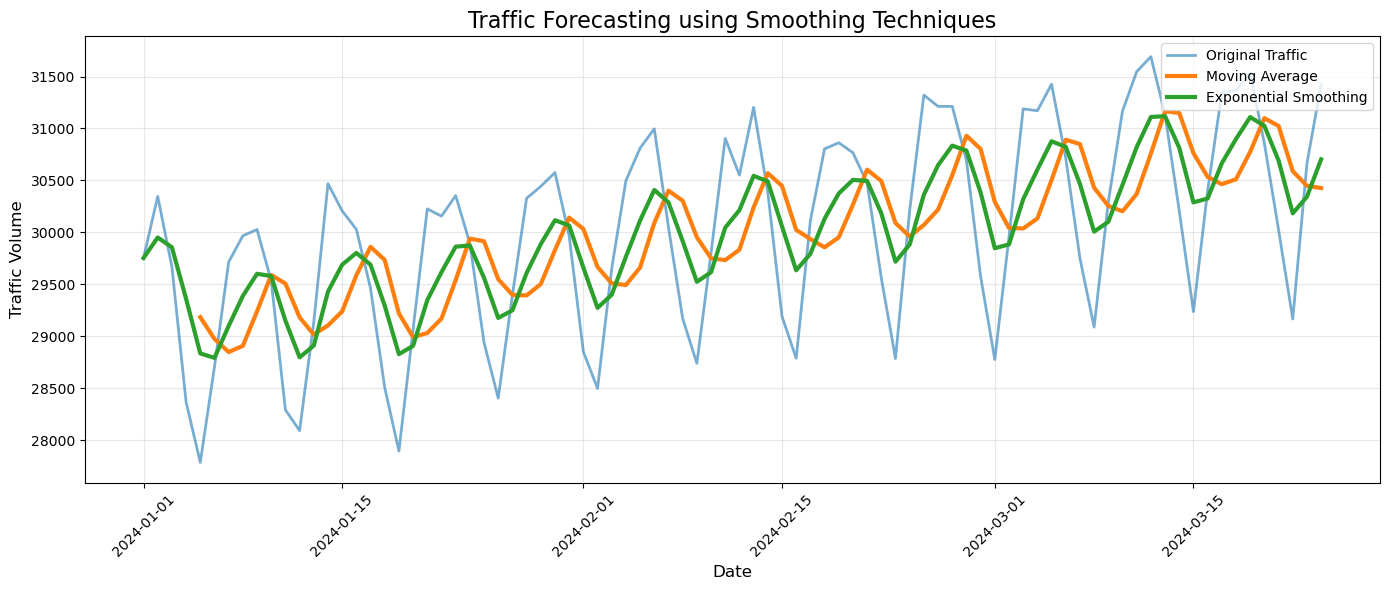

In [7]:
# Plot forecasting results

plt.figure(figsize=(14,6))

# Original Traffic
plt.plot(
    traffic_data['Date'],
    traffic_data['Traffic_Volume'],
    label='Original Traffic',
    alpha=0.6,
    linewidth=2
)

# Moving Average
plt.plot(
    traffic_data['Date'],
    traffic_data['Moving_Average'],
    label='Moving Average',
    linewidth=3
)

# Exponential Smoothing
plt.plot(
    traffic_data['Date'],
    traffic_data['Exponential_Smoothing'],
    label='Exponential Smoothing',
    linewidth=3
)

# Title and Labels
plt.title(
    "Traffic Forecasting using Smoothing Techniques",
    fontsize=16
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Traffic Volume", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(loc='upper right')

# Adjust layout
plt.tight_layout()

# Show graph
plt.show()